# Ejercicio 1: Evaluación de solicitud de crédito bancario

### Ficha PEAS

| Elemento | Descripción |
|---|---|
| **Percepción (S)** | Ingreso mensual del solicitante, monto solicitado e historial de morosidad. |
| **Acciones (A)** | Aprobar, aprobar con condiciones o rechazar la solicitud de crédito. |
| **Entorno (E)** | Sistema bancario, clientes solicitantes de crédito y registros financieros del banco. |
| **Objetivo** | Evaluar el riesgo de la solicitud y tomar una decisión considerando la capacidad de pago y el historial del solicitante. |
| **Medida de desempeño (P)** | Maximizar decisiones de crédito adecuadas, reduciendo el riesgo de impago y evitando rechazar innecesariamente solicitudes de bajo riesgo. |

### Justificación de las reglas

Para la toma de decisiones se utilizarán las siguientes reglas:

- **Aprobar:** relación monto/ingreso menor o igual a 0.30 y sin historial moroso.
- **Aprobar con condiciones:** relación menor o igual a 0.30 con historial moroso, o relación mayor a 0.30 y menor o igual a 0.50 sin historial moroso.
- **Rechazar:** relación mayor a 0.30 y menor o igual a 0.50 con historial moroso, o cualquier solicitud cuya relación sea mayor a 0.50.

Estas reglas consideran la relación entre el monto solicitado y el ingreso mensual como un indicador para evaluar la solicitud. Una relación baja y sin historial moroso representa un menor riesgo para el banco. Cuando la relación aumenta o existe historial moroso, el riesgo también aumenta, por lo que se aplican condiciones adicionales o se rechaza la solicitud.

### Código

In [10]:
def agente_credito(ingreso_mensual, monto_solicitado, tiene_historial_moroso):
    # Validar que el ingreso mensual sea mayor que cero
    if ingreso_mensual <= 0:
        return "rechazar", "el ingreso mensual debe ser mayor que cero"

    # Calcular la relación entre el monto solicitado y el ingreso mensual
    relacion = monto_solicitado / ingreso_mensual

    # Relación baja
    if relacion <= 0.30:
        if tiene_historial_moroso:
            return "aprobar con condiciones", f"relación monto/ingreso de {relacion:.2f} con historial moroso"
        else:
            return "aprobar", f"relación monto/ingreso de {relacion:.2f} sin historial moroso"

    # Relación intermedia
    elif relacion <= 0.50:
        if tiene_historial_moroso:
            return "rechazar", f"relación monto/ingreso de {relacion:.2f} con historial moroso"
        else:
            return "aprobar con condiciones", f"relación monto/ingreso de {relacion:.2f} sin historial moroso"

    # Relación alta
    else:
        return "rechazar", f"relación monto/ingreso de {relacion:.2f}, superior al límite de 0.50"

### Simulación y pruebas

Se evalúan diferentes solicitudes para comprobar el comportamiento del agente ante distintos niveles de relación monto/ingreso e historial de morosidad. Se incluyen casos de aprobación, aprobación con condiciones, rechazo y valores ubicados en los límites de decisión.

In [11]:
casos_prueba = [
    (5000, 1000, False),  # Relación 0.20
    (5000, 1500, False),  # Relación 0.30 - caso límite
    (5000, 1500, True),   # Relación 0.30 con historial moroso
    (5000, 2000, False),  # Relación 0.40
    (5000, 2500, True),   # Relación 0.50 - caso límite con historial
    (5000, 3000, False)   # Relación 0.60
]

for ingreso, monto, historial in casos_prueba:
    relacion = monto / ingreso
    accion, motivo = agente_credito(ingreso, monto, historial)

    print(f"Ingreso: S/ {ingreso}")
    print(f"Monto solicitado: S/ {monto}")
    print(f"Historial moroso: {historial}")
    print(f"Relación monto/ingreso: {relacion:.2f}")
    print(f"Decisión: {accion}")
    print(f"Motivo: {motivo}")
    print("-" * 50)

Ingreso: S/ 5000
Monto solicitado: S/ 1000
Historial moroso: False
Relación monto/ingreso: 0.20
Decisión: aprobar
Motivo: relación monto/ingreso de 0.20 sin historial moroso
--------------------------------------------------
Ingreso: S/ 5000
Monto solicitado: S/ 1500
Historial moroso: False
Relación monto/ingreso: 0.30
Decisión: aprobar
Motivo: relación monto/ingreso de 0.30 sin historial moroso
--------------------------------------------------
Ingreso: S/ 5000
Monto solicitado: S/ 1500
Historial moroso: True
Relación monto/ingreso: 0.30
Decisión: aprobar con condiciones
Motivo: relación monto/ingreso de 0.30 con historial moroso
--------------------------------------------------
Ingreso: S/ 5000
Monto solicitado: S/ 2000
Historial moroso: False
Relación monto/ingreso: 0.40
Decisión: aprobar con condiciones
Motivo: relación monto/ingreso de 0.40 sin historial moroso
--------------------------------------------------
Ingreso: S/ 5000
Monto solicitado: S/ 2500
Historial moroso: True
Rel

### Visualización

Se generan 200 solicitudes aleatorias variando el ingreso mensual, el monto solicitado y el historial de morosidad. Cada solicitud es evaluada por el agente y se representa en un gráfico de dispersión según la relación monto/ingreso y el ingreso mensual.

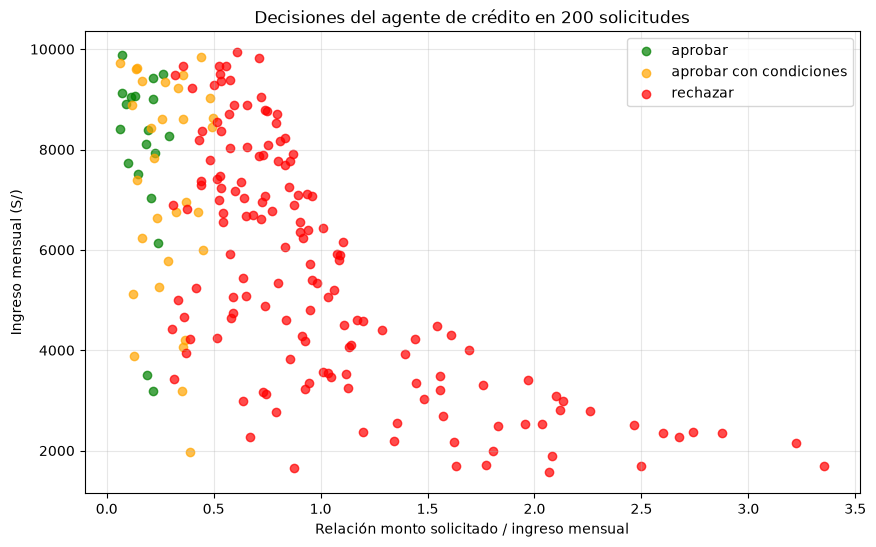

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Semilla para obtener resultados reproducibles
np.random.seed(42)

# Generar 200 solicitudes aleatorias
cantidad = 200

ingresos = np.random.randint(1500, 10001, cantidad)
montos = np.random.randint(500, 7001, cantidad)
historiales = np.random.choice([True, False], cantidad)

# Listas para almacenar resultados
relaciones = []
decisiones = []

# Evaluar cada solicitud con el agente
for ingreso, monto, historial in zip(ingresos, montos, historiales):
    relacion = monto / ingreso
    accion, motivo = agente_credito(ingreso, monto, historial)

    relaciones.append(relacion)
    decisiones.append(accion)

# Representar cada tipo de decisión
colores = {
    "aprobar": "green",
    "aprobar con condiciones": "orange",
    "rechazar": "red"
}

plt.figure(figsize=(10, 6))

for decision in colores:
    indices = [i for i, accion in enumerate(decisiones) if accion == decision]

    plt.scatter(
        [relaciones[i] for i in indices],
        [ingresos[i] for i in indices],
        label=decision,
        color=colores[decision],
        alpha=0.7
    )

plt.xlabel("Relación monto solicitado / ingreso mensual")
plt.ylabel("Ingreso mensual (S/)")
plt.title("Decisiones del agente de crédito en 200 solicitudes")
plt.legend()
plt.grid(alpha=0.3)
plt.show()